Import libraries and data to be used

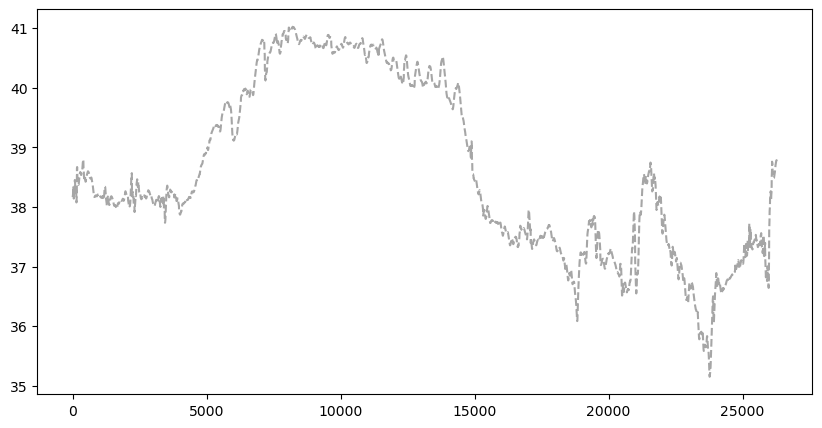

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#define the raw data paths and read in the unnormalized yaw data for L1
l1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_L1 - 002F29E4\euler.csv"
l1_yaw_un_norm = pd.read_csv(l1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for S1
s1_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_S1 - 002F2E12\euler.csv"
s1_yaw_un_norm = pd.read_csv(s1_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized yaw data for the winch
winch_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\NGIMU_Winch - 002D4F6B\euler.csv"
winch_yaw_un_norm = pd.read_csv(winch_path, skiprows=1, header=None, usecols=[3]).values

#define the raw data paths and read in the unnormalized force data
force_path=r"C:\Users\awatt\OneDrive\Documents\Spine-Stiffness-Python\FullTestForce_020422_1.txt"
force_data_raw = pd.read_csv(force_path,sep=r'\s+', header=None)

#extract the untrimmed force and event marker data from the raw force data
force_untrimmed = force_data_raw[0].values
em_untrimmed = force_data_raw[1].values


# Plot the original data 
plt.figure(figsize=(10, 5))
plt.plot(l1_yaw_un_norm.flatten(), label='Original Data (Un-normalized)', color='gray', linestyle='--', alpha=0.7)
plt.show()


Time normalise all Yaw data from IMUs to make them the same length using linear interpolation

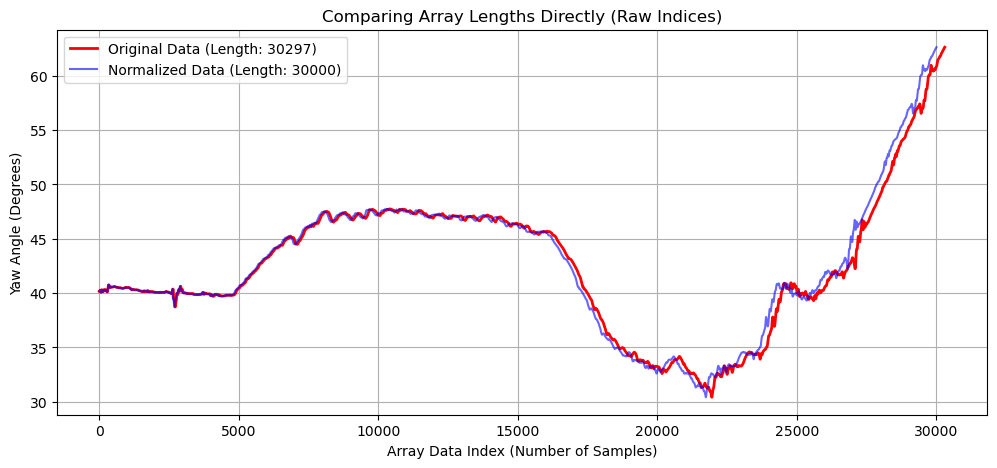

In [ ]:
from scipy.interpolate import interp1d

def time_normalize_signal(x, target_length=30000):
    
    """Time-normalizes a signal to a specified target length using interpolation."""#
    x_flat=x.flatten()
    original_length=len(x_flat)
    old_time = np.arange(0, original_length)
    interpolator = interp1d(old_time, x_flat, kind='linear', bounds_error=True)
    new_time = np.linspace(0, original_length - 1, target_length)
    return interpolator(new_time)

l1_yaw_norm = time_normalize_signal(l1_yaw_un_norm)
s1_yaw_norm = time_normalize_signal(s1_yaw_un_norm)
winch_yaw_norm = time_normalize_signal(winch_yaw_un_norm)

# Plot the original and normalized data for S1 to compare lengths
plt.figure(figsize=(12, 5))
plt.plot(s1_yaw_un_norm.flatten(), label=f'Original Data (Length: {len(s1_yaw_un_norm)})', color='red', linewidth=2)
plt.plot(s1_yaw_norm, label=f'Normalized Data (Length: {len(s1_yaw_norm)})', color='blue', alpha=0.6)
plt.title('Comparing Array Lengths Directly (Raw Indices)')
plt.xlabel('Array Data Index (Number of Samples)')
plt.ylabel('Yaw Angle (Degrees)')
plt.legend()
plt.grid(True)
plt.show()


Trim the force data to the length denoted by the start and end event markers

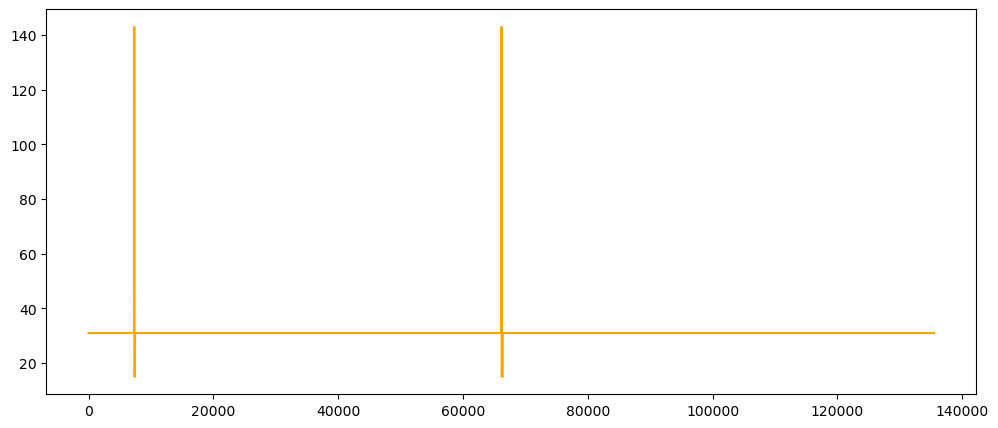

True Trial Start (First Rising Edge): 7299
True Trial End (Second Rising Edge): 66159


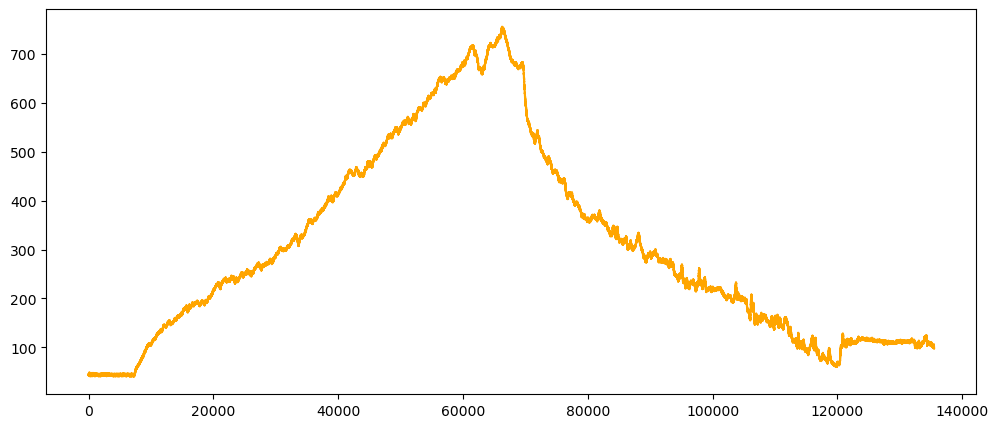

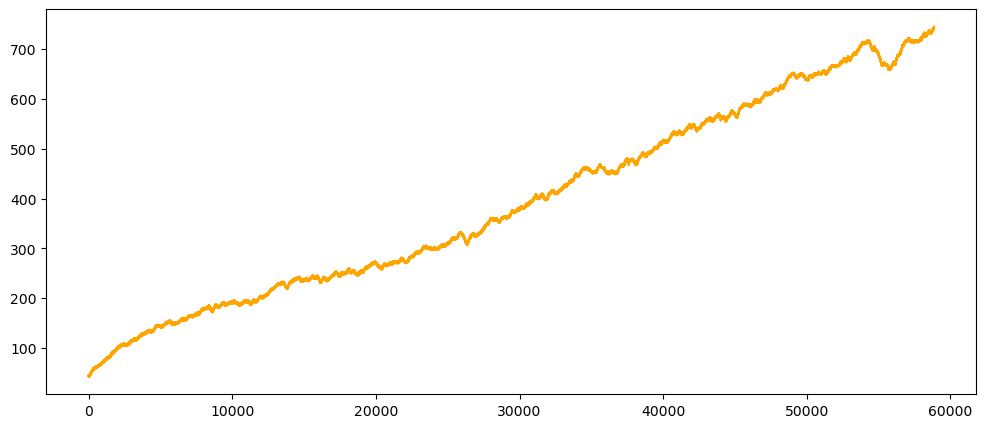

In [65]:
plt.figure(figsize=(12, 5))
plt.plot(em_untrimmed, label='Event Markers (Untrimmed)', color='orange')
plt.show()

# Create a binary map (True/False or 1/0) of where the signal is above threshold
threshold = 100
above_threshold = (em_untrimmed > threshold).astype(int)

# Calculate the difference to find rising edges (where it goes from 0 to 1)
jumps = np.diff(above_threshold)
rising_edges = np.where(jumps == 1)[0]

# Extract start and end indices
start_index = rising_edges[0]
end_index = rising_edges[1]

print(f"True Trial Start (First Rising Edge): {start_index}")
print(f"True Trial End (Second Rising Edge): {end_index}")

# Trim the force data using the identified indices from the event marker data
force_trimmed = force_untrimmed[start_index:end_index]

plt.figure(figsize=(12, 5))
plt.plot(force_untrimmed, label='Force Data (Trimmed)', color='orange')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(force_trimmed, label='Force Data (Trimmed)', color='orange')
plt.show()
